# Load dataset

In [ ]:
import pandas as pd
df = pd.read_csv('cleaned_dataset.csv')
df.head(10)

# Data inspection

In [7]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39787 entries, 0 to 39786
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    39787 non-null  object
 1   label   39787 non-null  object
dtypes: object(2)
memory usage: 621.8+ KB


In [9]:
df.isnull().sum()
df.nunique()

text     39573
label        2
dtype: int64

In [16]:
size=df.groupby('label').size()
print(size)

label
halal    21826
haram    17961
dtype: int64


<Axes: xlabel='label'>

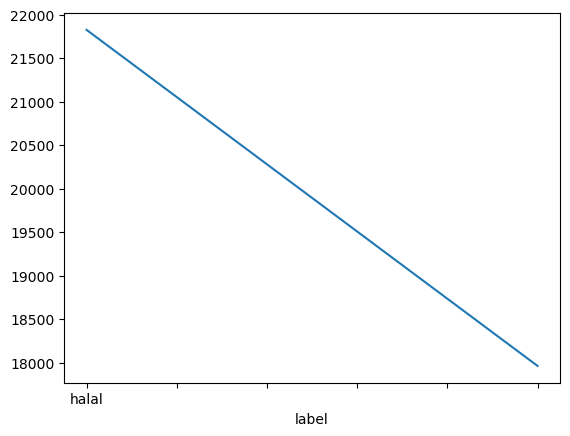

In [14]:
size.plot()

In [24]:
df.duplicated().sum()

np.int64(0)

# Data cleaning

In [23]:
df = df.drop_duplicates()

In [26]:
df['text']=df['text'].str.strip()

C:\Users\Muhammad Tahir\AppData\Local\Temp\ipykernel_10624\269230683.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['text']=df['text'].str.strip()


In [27]:
df['label']=df['label'].str.strip()

C:\Users\Muhammad Tahir\AppData\Local\Temp\ipykernel_10624\1964780830.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label']=df['label'].str.strip()


In [35]:
#one hot encoding for labels
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(df["label"])
df["label_encoded"] = y_encoded


C:\Users\Muhammad Tahir\AppData\Local\Temp\ipykernel_10624\896070749.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["label_encoded"] = y_encoded


# Fetaure Selection

In [39]:
X=df['text']
y=df['label']

# Split data

In [40]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [42]:
len(X_test)

7915

# TD-IDF 

In [66]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Saving File

In [68]:
df.to_csv("updated_cleaned_dataset.csv", index=False)

In [67]:
df2 = pd.read_csv("updated_cleaned_dataset.csv")

In [69]:
df2.head(10)

,text,label,label_encoded
0,vegetable oil,halal,0
1,beef stock contains less than of mirepoix carr...,halal,0
2,clam stock potatoes clams cream vegetable oil ...,haram,1
3,water cream broccoli celery vegetable oil corn...,haram,1
4,chicken stock contains less than of yeast extr...,halal,0
5,water pea beans carrots cooked ham water added...,haram,1
6,diced tomatoes in tomato juice tomato puree wa...,halal,0
7,tomato puree water tomato paste water high fru...,halal,0
8,water tomato puree water tomato paste chicken ...,haram,1
9,prepared navy beans water brown sugar onion to...,halal,0


# Logistic Regression

In [50]:
from sklearn.linear_model import LogisticRegression

In [51]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
y_pred = model.predict(X_test_tfidf)

In [56]:
results = pd.DataFrame({
    "text": X_test,
    "actual": y_test,
    "predicted": y_pred
})

print(results.head(10))

                                                    text actual predicted
5557   pepperoni stick beef pork water salt contains ...  haram     haram
6361   cooked scallop trim meat sorbitol fish sauce s...  haram     haram
21701  fresh cucumbers fructose water salt vinegar mu...  halal     halal
11873                                    organic mangoes  halal     halal
4217   pork non fat dry milk sea salt contains less t...  haram     haram
17034     extra virgin olive oil soy lecithin propellant  halal     halal
29303  water dried cane syrup rice flour eggs palm oi...  haram     haram
27166  reduced fat mozzarella cheese pasteurized part...  haram     haram
26278  wheat flour sugar vegetable oil palm oil sunfl...  haram     haram
29699  organic spinach organic unbleached wheat flour...  haram     haram


# Evaluation

In [57]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.9656348704990524

In [58]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       halal       0.95      0.99      0.97      4312
       haram       0.98      0.94      0.96      3603

    accuracy                           0.97      7915
   macro avg       0.97      0.96      0.97      7915
weighted avg       0.97      0.97      0.97      7915



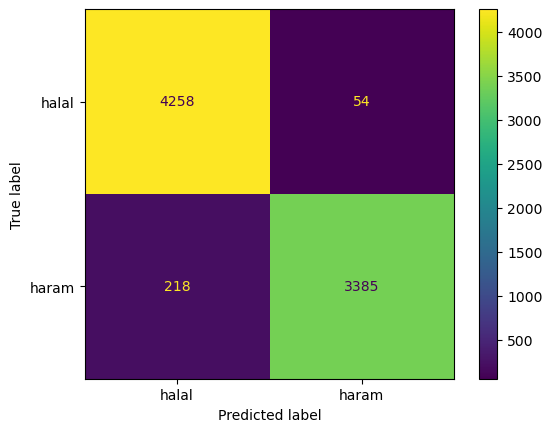

In [59]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

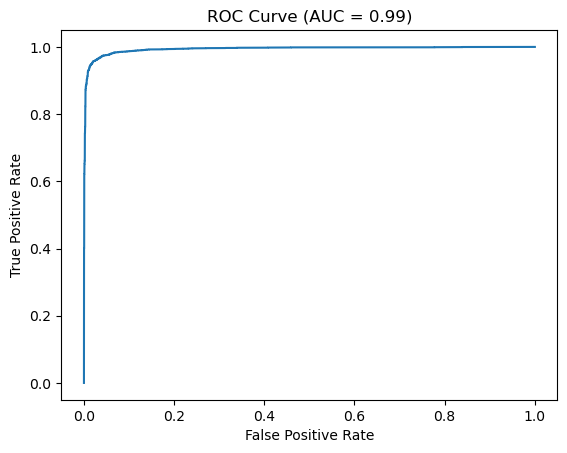

In [65]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_proba = model.predict_proba(X_test_tfidf)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba, pos_label="haram")
auc = roc_auc_score(y_test, y_proba)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc:.2f})")
plt.show()